# GNN Autoencoder

- A GNN Autoencoder is an autoencoder designed for graph data.
- GNN Autoencoder learns node embeddings by aggregating neighbor information and reconstructing graph connections.
- 🔑 It compresses a graph
- 🔑 Then reconstructs the graph structure

📌 Used when data is:

- Nodes + edges
- Relationships matter more than order

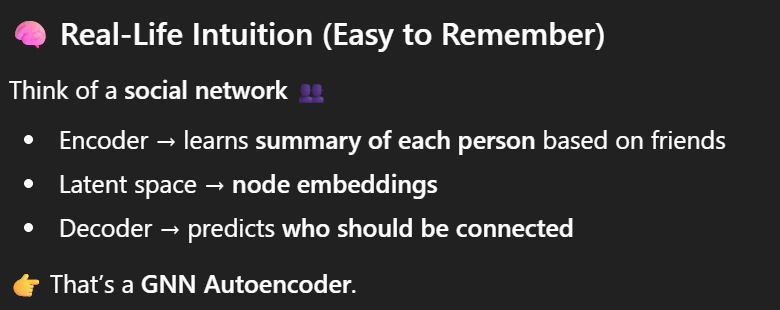

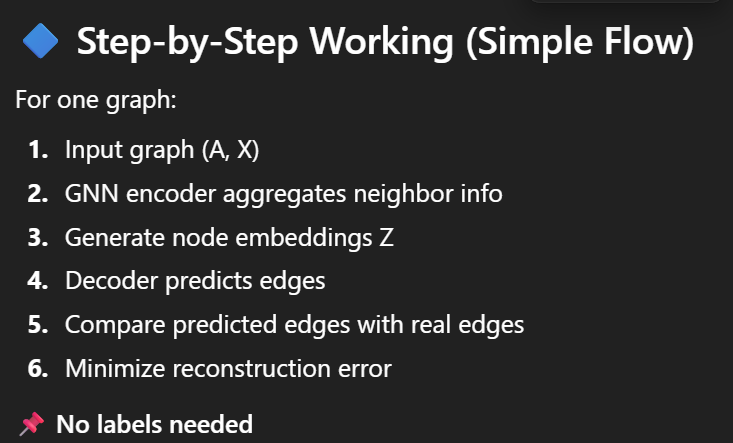

--- 

# Implementation

In [13]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

In [14]:
x = torch.tensor([
    [1.0, 0.5, 0.3],
    [0.9, 0.1, 0.8],
    [0.2, 0.7, 0.4],
    [0.6, 0.9, 0.1]
])
edge_index = torch.tensor([
    [0, 1, 1, 2, 2, 3],
    [1, 0, 2, 1, 3, 2]
], dtype=torch.long)
adj_matrix = torch.tensor([
    [0, 1, 0, 0],
    [1, 0, 1, 0],
    [0, 1, 0, 1],
    [0, 0, 1, 0]
], dtype=torch.float)


In [15]:
class GNNEncoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return x


In [16]:
def decode(z):
    return torch.sigmoid(torch.matmul(z, z.t()))

In [17]:
class GNNAutoencoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.encoder = GNNEncoder(in_channels, hidden_channels)

    def forward(self, x, edge_index):
        z = self.encoder(x, edge_index)
        adj_recon = decode(z)
        return adj_recon, z



In [18]:
model = GNNAutoencoder(in_channels=3, hidden_channels=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(200):
    optimizer.zero_grad()
    
    adj_pred, z = model(x, edge_index)
    
    loss = F.binary_cross_entropy(adj_pred, adj_matrix)
    loss.backward()
    optimizer.step()
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")


Epoch 0, Loss: 0.7552
Epoch 20, Loss: 0.6940
Epoch 40, Loss: 0.6933
Epoch 60, Loss: 0.6930
Epoch 80, Loss: 0.6929
Epoch 100, Loss: 0.6928
Epoch 120, Loss: 0.6927
Epoch 140, Loss: 0.6926
Epoch 160, Loss: 0.6925
Epoch 180, Loss: 0.6923
